# Rule별 N회 반복 분포 비교

`COMPOSITE`, `MIN_QTIME` 등을 N회씩 돌려 Makespan / Qtime Violation의 **분포(boxplot)** 와 **평균/표준편차**를 본다.

- `RULES` 리스트를 수정하면 비교 대상 rule을 자유롭게 바꿀 수 있다.
- COMPOSITE rule은 `(JOB_RULE, composite_w)` 형식.
- 같은 seed 집합(CRN)을 모든 rule에 적용해 paired 비교가 가능하다.

## 환경 설정

In [1]:
import os
import json
import random
import time
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging
from dotenv import load_dotenv

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
import matplotlib.font_manager as fm
# 한글 폰트: 선호 순서대로 두되 '실제 설치된' 것만 적용 → 미설치 폰트 findfont 경고 방지
_installed_fonts = {f.name for f in fm.fontManager.ttflist}
plt.rcParams['font.family'] = [f for f in ['Noto Sans KR', 'Malgun Gothic'] if f in _installed_fonts] + ['sans-serif']
plt.rcParams['axes.unicode_minus'] = False

load_dotenv(override=True)

BASE_DATA_PATH = os.getenv('BASE_DATA_PATH', 'data')
PM_HAZARD_THRESHOLD = float(os.getenv('PM_HAZARD_THRESHOLD', '0.1'))

# 분포를 보려면 시뮬레이션에 stochasticity가 있어야 한다 → DOWN_ACTIVE=True 권장.
# .env가 False로 설정돼 있어도 여기서 명시적으로 덮어쓴다.
PM_ACTIVE = False
DOWN_ACTIVE = True
os.environ['PM_ACTIVE'] = 'True' if PM_ACTIVE else 'False'
os.environ['DOWN_ACTIVE'] = 'True' if DOWN_ACTIVE else 'False'
os.environ['PM_RULE'] = 'THRESHOLD'
# 단위 안정화: 내부 계산은 분(M)으로 통일 — boxplot 축에서 분 단위로 표시.
os.environ['TIME_UNIT'] = 'M'

print(f"BASE_DATA_PATH = {BASE_DATA_PATH}")
print(f"PM_HAZARD_THRESHOLD = {PM_HAZARD_THRESHOLD}")
print(f"PM_ACTIVE = {PM_ACTIVE}, DOWN_ACTIVE = {DOWN_ACTIVE}")

BASE_DATA_PATH = data
PM_HAZARD_THRESHOLD = 0.5
PM_ACTIVE = False, DOWN_ACTIVE = True


## 모듈 import 및 데이터 로드

In [2]:
from utils import DataLoader, EventLogger
from simulation import Scheduler
from simulation.priority import set_transition_risk_table

data_loader = DataLoader(BASE_DATA_PATH)
data = data_loader.load_all_data()
print(f"Jobs: {len(data['jobs'])} / Operations: {len(data['operations'])} / Machines: {len(data['machines'])}")

# AQT 분모: data schema 기반 job 수 (grid_search / saa_evaluator와 동일 규약)
N_JOBS = int(len(data['jobs']))
if N_JOBS <= 0:
    raise ValueError("data['jobs']가 비어 있어 AQT 분모를 만들 수 없다.")
print(f"N_JOBS (AQT 분모) = {N_JOBS}")

# transition 위험 테이블 로드 (없으면 γ 항 무효)
RISK_CACHE = os.path.join('tuning', 'transition_risk.json')
if os.path.exists(RISK_CACHE):
    with open(RISK_CACHE, 'r', encoding='utf-8') as f:
        _risk_table = json.load(f)
    set_transition_risk_table(_risk_table)
    print(f"transition risk table loaded: {_risk_table}")
else:
    print(f"[WARN] {RISK_CACHE} not found → γ 항 무효")

Jobs: 60 / Operations: 870 / Machines: 60
N_JOBS (AQT 분모) = 60
transition risk table loaded: {'G1->G3': 0.6, 'G1->G4': 1.0, 'G4->G1': 0.5714285714285715}


## 비교 대상 Rule 설정

각 항목은 `(label, job_rule, composite_w)` 형식.
- `job_rule`이 `'COMPOSITE'`가 아니면 `composite_w`는 무시된다.
- `composite_w`는 6항 고정 계수 리스트 `[PT, SLACK, SETUP, C_TRANSITION, COMPLETION_FAST, WAITING]`. 값은 `.env` 의 `COMPOSITE_W_*` 에서 읽는다 (`run_full6_pso.ipynb` 의 w*).

In [3]:
# COMPOSITE 6항 고정 계수 — .env 의 COMPOSITE_W_* 에서 읽는다.
# 항(term)은 6개로 고정. 사용자는 .env 의 6개 숫자(run_full6_pso 결과 w*)만 바꾸면 된다.
# scale-invariant 라 합=1 이 아니어도 동일 dispatch (composite_select 는 argmin).
COMPOSITE_TERMS_FIXED = ['PT', 'SLACK', 'SETUP', 'C_TRANSITION', 'COMPLETION_FAST', 'WAITING']
W_COMPOSITE = [float(os.getenv(f'COMPOSITE_W_{t}', '0.0')) for t in COMPOSITE_TERMS_FIXED]

print('COMPOSITE 6항 계수 (.env COMPOSITE_W_*):')
for t, w in zip(COMPOSITE_TERMS_FIXED, W_COMPOSITE):
    print(f'  {t:16s} = {w}')
if sum(abs(w) for w in W_COMPOSITE) == 0:
    print('[WARN] 모든 계수가 0 → .env 의 COMPOSITE_W_* 를 입력하세요.')

# (label, job_rule, composite_w)
RULES = [
    ('COMPOSITE', 'COMPOSITE', W_COMPOSITE),
    ('MIN_QTIME', 'MIN_QTIME', None),
]

# 반복 횟수 & seed 기준 (모든 rule에 같은 seed 적용 → CRN)
N_RUNS = 30
BASE_SEED = 0

print(f"\n비교 대상 {len(RULES)}개 rule × {N_RUNS}회 = 총 {len(RULES)*N_RUNS}회 시뮬레이션")

COMPOSITE 6항 계수 (.env COMPOSITE_W_*):
  PT               = 0.0
  SLACK            = 0.4323
  SETUP            = 0.4078
  C_TRANSITION     = 0.0646
  COMPLETION_FAST  = 0.0435
  WAITING          = 0.0519

비교 대상 2개 rule × 30회 = 총 60회 시뮬레이션


## 시뮬레이션 실행

In [4]:
# operations 메타: op_id → 'prev_op_group->op_group' transition 라벨
_op_meta = data['operations'][['job_id', 'op_id', 'op_seq', 'op_group']].copy()
_prev_meta = _op_meta.copy()
_prev_meta['op_seq'] = _prev_meta['op_seq'] + 1
_prev_meta = _prev_meta.rename(columns={'op_group': 'prev_op_group'})[
    ['job_id', 'op_seq', 'prev_op_group']
]
_op_with_prev = _op_meta.merge(_prev_meta, on=['job_id', 'op_seq'], how='left')
_op_with_prev['transition'] = (
    _op_with_prev['prev_op_group'].fillna('START') + '->' + _op_with_prev['op_group']
)
OP_TRANSITION_MAP = _op_with_prev.set_index('op_id')['transition'].to_dict()


def count_inproc_breakdowns(log_df):
    """작업(setup/working) 도중 고장으로 재투입된 횟수.

    breakdown으로 run()이 interrupt되면 is_completed=False → job.cur_seq가
    유지된 채 같은 op로 WAITING에 재진입한다 (PM은 preempt=False라 run을
    중단시키지 않으므로, 같은 op로의 재대기는 오직 고장에 의해서만 발생).
    따라서 job별 WAITING 이벤트의 op_id가 직전과 동일하게 연속된 case를
    세면 곧 '처리 중 고장 발생 횟수'가 된다.
    """
    jl = log_df[(log_df['resource'] == 'job') &
                (log_df['event'].str.startswith('waiting'))].sort_values(['id', 'start'])
    same = (jl['id'] == jl['id'].shift()) & (jl['op_id'] == jl['op_id'].shift())
    return int(same.sum())


def run_simulation(job_rule, composite_w, seed):
    """단일 시뮬레이션 실행 → (makespan, qtime_violation_total, transition_dict, inproc_breakdowns).

    transition_dict: {'G1->G3': violation_minutes, ...}
    qtime_violation_total은 분 단위 총합. AQT는 호출부에서 N_JOBS로 나눠 사용.
    inproc_breakdowns: 작업 중 고장으로 재투입된 횟수 (PM cost 간접 지표).
    """
    os.environ['JOB_RULE'] = job_rule
    if job_rule == 'COMPOSITE':
        # Dynamic 6항 모드: 고정 항(COMPOSITE_TERMS_FIXED) + .env 계수(composite_w)
        os.environ['COMPOSITE_TERMS'] = ','.join(COMPOSITE_TERMS_FIXED)
        os.environ['COMPOSITE_WEIGHTS'] = ','.join(str(float(w)) for w in composite_w)

    random.seed(seed)
    env = simpy.Environment()
    logger = EventLogger(env)
    scheduler = Scheduler(
        env=env, data=data, event_logger=logger,
        pm_hazard_threshold=PM_HAZARD_THRESHOLD,
    )
    env.run(until=scheduler.job_chk_process)
    log_df = pd.DataFrame(logger.logs)

    # makespan: 마지막 job 완료 시각
    job_log = log_df[log_df['resource'] == 'job']
    makespan = float(job_log.groupby('id')['finish'].max().max())

    # qtime violation 총합 + transition별 분해
    qv = log_df[log_df['event'] == 'qtime_over'].copy()
    if len(qv) > 0:
        qv['violation'] = qv['finish'] - qv['start']
        qv['transition'] = qv['op_id'].map(OP_TRANSITION_MAP)
        qtime_total = float(qv['violation'].sum())
        trans_dict = qv.groupby('transition')['violation'].sum().to_dict()
    else:
        qtime_total = 0.0
        trans_dict = {}

    # 작업 중 고장 발생 횟수 (PM 효과 간접 지표)
    inproc_bd = count_inproc_breakdowns(log_df)

    return makespan, qtime_total, trans_dict, inproc_bd


records = []
records_trans = []
t_start = time.time()
for label, job_rule, composite_w in RULES:
    t0 = time.time()
    for i in range(N_RUNS):
        seed = BASE_SEED + i
        mk, qv, td, bd = run_simulation(job_rule, composite_w, seed)
        records.append({
            'rule': label,
            'run': i,
            'seed': seed,
            'makespan': mk,
            'qtime_violation': qv,      # 분, 총합 (transition 분해 등 raw용)
            'aqt': qv / N_JOBS,         # 분/job, 목적함수 단위
            'inproc_bd': bd,            # 작업 중 고장 발생 횟수
        })
        for trans, vio in td.items():
            records_trans.append({
                'rule': label,
                'pm_mode': 'PM Off',
                'run': i,
                'seed': seed,
                'transition': trans,
                'violation': vio,
            })
    print(f"  [{label:30s}] {N_RUNS}회 완료 ({time.time()-t0:.1f}s)")

metrics_df = pd.DataFrame(records)
metrics_trans_off = pd.DataFrame(records_trans)
print(f"\n총 소요 {time.time()-t_start:.1f}s, 결과 shape = {metrics_df.shape}")
metrics_df.head()


  [COMPOSITE                     ] 30회 완료 (27.2s)


  [MIN_QTIME                     ] 30회 완료 (9.0s)

총 소요 36.2s, 결과 shape = (60, 7)


,rule,run,seed,makespan,qtime_violation,aqt,inproc_bd
0,COMPOSITE,0,0,12627.478588,4099.210321,68.320172,27
1,COMPOSITE,1,1,12530.787343,4283.217073,71.386951,17
2,COMPOSITE,2,2,13597.036146,6451.844739,107.530746,25
3,COMPOSITE,3,3,13116.810510,7846.116679,130.768611,23
4,COMPOSITE,4,4,11891.062965,1343.058888,22.384315,16


## 평균 / 표준편차 / 표준오차 요약

In [5]:
def _summarize(df, col):
    grp = df.groupby('rule')[col]
    out = pd.DataFrame({
        'mean': grp.mean(),
        'std':  grp.std(ddof=1),
        'se':   grp.std(ddof=1) / np.sqrt(grp.count()),
        'min':  grp.min(),
        'median': grp.median(),
        'max':  grp.max(),
        'n':    grp.count(),
    })
    # RULES 순서를 유지
    order = [r[0] for r in RULES]
    return out.reindex(order)

summary_makespan = _summarize(metrics_df, 'makespan')
summary_aqt      = _summarize(metrics_df, 'aqt')

print("=== Makespan (분) ===")
print(summary_makespan.round(3).to_string())
print(f"\n=== AQT = Qtime Violation / N_JOBS (분/job, N_JOBS={N_JOBS}) ===")
print(summary_aqt.round(3).to_string())

=== Makespan (분) ===
                mean      std       se        min     median        max   n
rule                                                                       
COMPOSITE  12629.739  525.888   96.014  11459.633  12577.668  13648.032  30
MIN_QTIME  12656.533  596.784  108.957  11815.179  12595.114  14512.868  30

=== AQT = Qtime Violation / N_JOBS (분/job, N_JOBS=60) ===
              mean     std     se     min   median      max   n
rule                                                           
COMPOSITE   73.920  48.585   8.87  12.282   69.854  256.289  30
MIN_QTIME  120.435  65.341  11.93  31.837  115.178  362.013  30


## 요청 1 — PM Threshold별 성능 비교 (수치 표)

`COMPOSITE` rule + `PM_RULE=THRESHOLD` 에서 `PM_HAZARD_THRESHOLD` 를 **0.05 / 0.1 / 0.15 / 0.3 / 0.5 / 0.7 / 0.85** 로 바꿔가며
각 threshold당 `N_RUNS`회(CRN seed 공유) 돌린 뒤, threshold별 **평균 수치 표**를 만든다.

| 항목 | 의미 | 단위 |
|---|---|---|
| Makespan | 마지막 job 완료 시각 | 시간(H) |
| AQT | Q-time 위반 총합 / `N_JOBS` | 시간/job |
| Breakdown during Processing | 작업(setup/working) 중 고장 재투입 횟수 | 횟수 |
| Objective Value (J) | `makespan/mk_ref + AQT/qv_ref_aqt` (SAA 목적함수, w1=w2=1) | 무차원 |

> 내부 계산은 분(M)이며, 표/그래프 표시만 Makespan·AQT 를 시간(÷60)으로 환산한다.
> `J` 는 분자/분모가 같은 단위라 시간 환산과 무관하게 값이 동일하다.
> `mk_ref`/`qv_ref_aqt` 는 GA/PSO fitness 와 동일하게 `tuning/full6_pso_result.json` 의 `config` 에서 읽는다.
> 여기서 계산한 `thr_df` 는 하단 "민감도 분석" 의 boxplot 에서 그대로 재사용된다(중복 실행 없음).

In [6]:
# ── 요청 1: PM Threshold 스윕 → 평균 수치 표 ─────────────────────────────────
# J(목적함수) 정규화 상수: GA/PSO fitness 와 동일하게 tuning/full6_pso_result.json 에서 로드.
with open(os.path.join('tuning', 'full6_pso_result.json'), 'r', encoding='utf-8') as f:
    _pso_cfg = json.load(f)['config']
MK_REF     = float(_pso_cfg['mk_ref'])       # 분 단위 makespan 기준
QV_REF_AQT = float(_pso_cfg['qv_ref_aqt'])   # 분/job 단위 AQT 기준
W1, W2 = 1.0, 1.0                            # SAA 목적함수 가중치 (GA/PSO 와 동일)
print(f"mk_ref = {MK_REF:.4f} (분), qv_ref_aqt = {QV_REF_AQT:.4f} (분/job)")


def objective_J(makespan_min, aqt_min):
    """SAA 목적함수 J = w1·makespan/mk_ref + w2·AQT/qv_ref_aqt (입력은 분 단위).

    분자/분모가 같은 분 단위라 J 자체는 단위 무관(시간으로 환산해도 값 동일).
    """
    return W1 * (makespan_min / MK_REF) + W2 * (aqt_min / QV_REF_AQT)


PM_THRESHOLDS = [0.05, 0.1, 0.15, 0.3, 0.5, 0.7, 0.85]


def run_simulation_pm_threshold(threshold, seed):
    """COMPOSITE + PM_RULE=THRESHOLD 를 주어진 PM_HAZARD_THRESHOLD 로 1회 실행.

    반환: (makespan, qtime_violation_total, inproc_breakdowns) — 시간은 분 단위.
    """
    os.environ['JOB_RULE'] = 'COMPOSITE'
    os.environ['COMPOSITE_TERMS'] = ','.join(COMPOSITE_TERMS_FIXED)
    os.environ['COMPOSITE_WEIGHTS'] = ','.join(str(float(w)) for w in W_COMPOSITE)

    random.seed(seed)
    env = simpy.Environment()
    logger = EventLogger(env)
    scheduler = Scheduler(
        env=env, data=data, event_logger=logger,
        pm_hazard_threshold=threshold,   # ← 스윕 대상
    )
    env.run(until=scheduler.job_chk_process)
    log_df = pd.DataFrame(logger.logs)

    job_log = log_df[log_df['resource'] == 'job']
    makespan = float(job_log.groupby('id')['finish'].max().max())

    qv = log_df[log_df['event'] == 'qtime_over']
    qtime_total = float((qv['finish'] - qv['start']).sum()) if len(qv) > 0 else 0.0

    inproc_bd = count_inproc_breakdowns(log_df)
    return makespan, qtime_total, inproc_bd


# PM 활성 + THRESHOLD rule 고정으로 스윕 실행 (CRN: 모든 threshold 에 같은 seed 집합)
os.environ['PM_ACTIVE'] = 'True'
os.environ['PM_RULE'] = 'THRESHOLD'

thr_records = []
t_start = time.time()
for thr in PM_THRESHOLDS:
    t0 = time.time()
    for i in range(N_RUNS):
        seed = BASE_SEED + i
        mk, qv, bd = run_simulation_pm_threshold(thr, seed)
        thr_records.append({
            'threshold': thr,
            'run': i,
            'seed': seed,
            'makespan': mk,                 # 분
            'qtime_violation': qv,          # 분, 총합
            'aqt': qv / N_JOBS,             # 분/job
            'inproc_bd': bd,                # 작업 중 고장 횟수
            'J': objective_J(mk, qv / N_JOBS),
        })
    print(f"  [threshold={thr:<5}] {N_RUNS}회 완료 ({time.time()-t0:.1f}s)")

# 환경 변수 원복 (노트북 기본값)
os.environ['PM_ACTIVE'] = 'False'
os.environ['PM_RULE'] = 'THRESHOLD'

thr_df = pd.DataFrame(thr_records)
print(f"\n총 소요 {time.time()-t_start:.1f}s, 결과 shape = {thr_df.shape}")

# ── threshold별 평균 수치 표 (요청 1 산출물) — Makespan/AQT 는 시간(H) 단위 ────
threshold_table = thr_df.groupby('threshold').agg(
    Makespan=('makespan', 'mean'),
    AQT=('aqt', 'mean'),
    Breakdown_during_Processing=('inproc_bd', 'mean'),
    Objective_Value_J=('J', 'mean'),
)
threshold_table['Makespan'] = threshold_table['Makespan'] / 60.0   # 분 → 시간
threshold_table['AQT'] = threshold_table['AQT'] / 60.0             # 분/job → 시간/job
threshold_table = (threshold_table
    .rename(columns={
        'Makespan': 'Makespan (시간)',
        'AQT': 'AQT (시간/job)',
        'Breakdown_during_Processing': 'Breakdown during Processing (횟수)',
        'Objective_Value_J': 'Objective Value (J)',
    })
    .round(3))
threshold_table.index.name = 'PM Threshold'

print("\n=== [요청 1] PM Threshold별 성능 비교 (N_RUNS 평균, 시간 단위) ===")
print(threshold_table.to_string())
threshold_table

mk_ref = 14734.1579 (분), qv_ref_aqt = 1140.0048 (분/job)


  [threshold=0.05 ] 30회 완료 (23.4s)


  [threshold=0.1  ] 30회 완료 (29.0s)


  [threshold=0.15 ] 30회 완료 (37.7s)


  [threshold=0.3  ] 30회 완료 (43.4s)


  [threshold=0.5  ] 30회 완료 (34.0s)


  [threshold=0.7  ] 30회 완료 (29.8s)


  [threshold=0.85 ] 30회 완료 (29.4s)

총 소요 226.7s, 결과 shape = (210, 8)

=== [요청 1] PM Threshold별 성능 비교 (N_RUNS 평균, 시간 단위) ===
              Makespan (시간)  AQT (시간/job)  Breakdown during Processing (횟수)  Objective Value (J)
PM Threshold                                                                                    
0.05                301.586         5.184                             5.700                1.501
0.10                250.285         1.240                             7.667                1.084
0.15                235.357         1.385                             9.400                1.031
0.30                218.242         1.189                            14.200                0.951
0.50                210.191         1.205                            18.767                0.919
0.70                210.084         1.232                            20.367                0.920
0.85                210.496         1.232                            20.433                0.922


,Makespan (시간),AQT (시간/job),Breakdown during Processing (횟수),Objective Value (J)
PM Threshold,,,,
0.05,301.586,5.184,5.700,1.501
0.10,250.285,1.240,7.667,1.084
0.15,235.357,1.385,9.400,1.031
0.30,218.242,1.189,14.200,0.951
0.50,210.191,1.205,18.767,0.919
0.70,210.084,1.232,20.367,0.920
0.85,210.496,1.232,20.433,0.922


## 요청 2 — COMPOSITE: PM Off vs PM Rule 적용 비교 (박스플롯 & 수치)

`COMPOSITE` rule 에 대해 **PM Off / THRESHOLD(0.5) / AGE_REPLACEMENT** 세 가지 PM 모드를 각각 `N_RUNS`회(CRN seed 공유) 돌려
4개 지표(**Makespan / AQT / Breakdown during Processing / Objective Value(J)**)의 **분포(boxplot)** 와 **평균 수치 표** 를 본다.

- THRESHOLD 모드는 `.env` 의 `PM_HAZARD_THRESHOLD` (= 0.5) 를 사용한다.
- PM Off 결과는 상단 `metrics_df`(PM=False) 를 그대로 재사용한다.
- 비교 대상 rule 은 COMPOSITE 이지만, 하단 transition 분석/`ga_result` 저장 셀이 쓰는 `MIN_QTIME` 도 함께 돌려 `metrics_all`/`metrics_trans` 를 채운다.

In [7]:
# ── 요청 2: PM 모드별 데이터 생성 (PM Off + THRESHOLD + AGE_REPLACEMENT) ─────
# PM=False 결과(metrics_df)는 그대로 'PM Off' 로 라벨링해 재사용.
metrics_off = metrics_df.copy()
metrics_off['pm_mode'] = 'PM Off'

# 비교할 PM rule (요청: THRESHOLD(0.5) + AGE_REPLACEMENT). MTTF 제외.
PM_RULES_ON = ['THRESHOLD', 'AGE_REPLACEMENT']

records_on = []
records_trans_on = []
t_start = time.time()
for pm_rule in PM_RULES_ON:
    os.environ['PM_ACTIVE'] = 'True'
    os.environ['PM_RULE']   = pm_rule
    print(f"=== PM=True / PM_RULE={pm_rule} (THRESHOLD={PM_HAZARD_THRESHOLD}) ===")
    for label, job_rule, composite_w in RULES:
        t0 = time.time()
        for i in range(N_RUNS):
            seed = BASE_SEED + i
            mk, qv, td, bd = run_simulation(job_rule, composite_w, seed)
            records_on.append({
                'rule': label,
                'pm_mode': pm_rule,
                'run': i,
                'seed': seed,
                'makespan': mk,
                'qtime_violation': qv,
                'aqt': qv / N_JOBS,
                'inproc_bd': bd,
            })
            for trans, vio in td.items():
                records_trans_on.append({
                    'rule': label,
                    'pm_mode': pm_rule,
                    'run': i,
                    'seed': seed,
                    'transition': trans,
                    'violation': vio,
                })
        print(f"  [{label:30s}] {N_RUNS}회 완료 ({time.time()-t0:.1f}s)")

# 환경 변수 원복 (PM=False 기본)
os.environ['PM_ACTIVE'] = 'False'
os.environ['PM_RULE']   = 'THRESHOLD'

metrics_on    = pd.DataFrame(records_on)
metrics_all   = pd.concat([metrics_off, metrics_on], ignore_index=True)
metrics_trans = pd.concat(
    [metrics_trans_off, pd.DataFrame(records_trans_on)], ignore_index=True
)

# Objective Value(J) 컬럼 추가 (요청 1과 동일 정의 — objective_J 재사용)
metrics_all['J'] = objective_J(metrics_all['makespan'], metrics_all['aqt'])

# rule 표시 순서 (하단 transition 분석 셀이 사용)
rule_labels = [r[0] for r in RULES]

# PM 모드 표시 순서/색상 (하단 transition 분석 셀도 이 변수를 사용)
PM_MODES = ['PM Off', 'THRESHOLD', 'AGE_REPLACEMENT']
PM_COLORS = {
    'PM Off':          'lightgray',
    'THRESHOLD':       'steelblue',
    'AGE_REPLACEMENT': 'indianred',
}

print(f"\n총 소요 {time.time()-t_start:.1f}s, PM=True 결과 shape = {metrics_on.shape}")
print(f"통합 metrics_all shape = {metrics_all.shape}")
print(f"transition 데이터 shape = {metrics_trans.shape}")
metrics_all.head()

=== PM=True / PM_RULE=THRESHOLD (THRESHOLD=0.5) ===


  [COMPOSITE                     ] 30회 완료 (28.1s)


  [MIN_QTIME                     ] 30회 완료 (9.9s)
=== PM=True / PM_RULE=AGE_REPLACEMENT (THRESHOLD=0.5) ===


  [COMPOSITE                     ] 30회 완료 (28.4s)


  [MIN_QTIME                     ] 30회 완료 (9.7s)

총 소요 76.0s, PM=True 결과 shape = (120, 8)
통합 metrics_all shape = (180, 9)
transition 데이터 shape = (383, 6)


,rule,run,seed,makespan,qtime_violation,aqt,inproc_bd,pm_mode,J
0,COMPOSITE,0,0,12627.478588,4099.210321,68.320172,27,PM Off,0.916950
1,COMPOSITE,1,1,12530.787343,4283.217073,71.386951,17,PM Off,0.913078
2,COMPOSITE,2,2,13597.036146,6451.844739,107.530746,25,PM Off,1.017149
3,COMPOSITE,3,3,13116.810510,7846.116679,130.768611,23,PM Off,1.004940
4,COMPOSITE,4,4,11891.062965,1343.058888,22.384315,16,PM Off,0.826676


### COMPOSITE — PM 모드별 4지표 박스플롯 & 수치 표

COMPOSITE rule 만 떼어, `PM Off / THRESHOLD / AGE_REPLACEMENT` 세 PM 모드를 4개 지표에 대해 나란히 그린다.
빨간 ×는 평균. 박스플롯 아래에 동일 4지표의 **평균 수치 표** 를 출력한다.

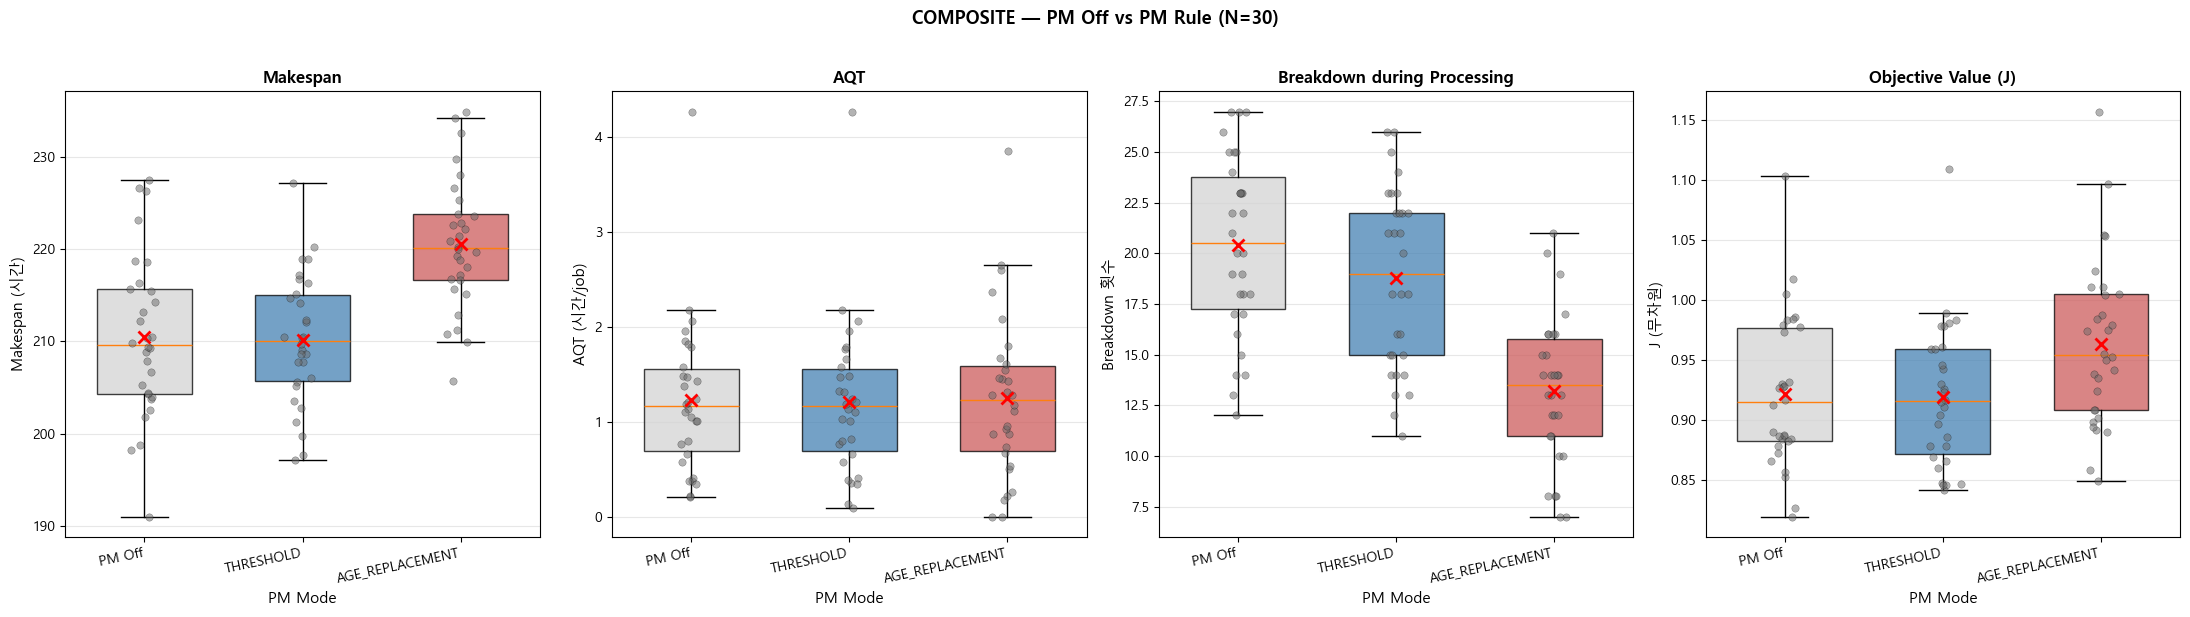

=== [요청 2] COMPOSITE PM 모드별 성능 비교 (N=30 평균, 시간 단위) ===
                 Makespan (시간)  AQT (시간/job)  Breakdown during Processing (횟수)  Objective Value (J)
PM Mode                                                                                            
PM Off                 210.496         1.232                            20.433                0.922
THRESHOLD              210.191         1.205                            18.767                0.919
AGE_REPLACEMENT        220.560         1.248                            13.200                0.964


,Makespan (시간),AQT (시간/job),Breakdown during Processing (횟수),Objective Value (J)
PM Mode,,,,
PM Off,210.496,1.232,20.433,0.922
THRESHOLD,210.191,1.205,18.767,0.919
AGE_REPLACEMENT,220.560,1.248,13.200,0.964


In [8]:
# ── 요청 2: COMPOSITE PM 모드별 4지표 박스플롯 (Makespan/AQT 는 시간 단위) ────
TARGET_RULE = 'COMPOSITE'
comp = metrics_all[metrics_all['rule'] == TARGET_RULE]

# (지표 컬럼, 표시 제목, y축 라벨, 분→표시단위 나눗셈)
#   Makespan/AQT 는 60 으로 나눠 시간(H), Breakdown/J 는 그대로.
METRIC_SPECS = [
    ('makespan', 'Makespan',                     'Makespan (시간)',          60.0),
    ('aqt',      'AQT',                           'AQT (시간/job)',           60.0),
    ('inproc_bd','Breakdown during Processing',   'Breakdown 횟수',           1.0),
    ('J',        'Objective Value (J)',           'J (무차원)',               1.0),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
for ax, (col, title, ylabel, div) in zip(axes, METRIC_SPECS):
    data = [comp[comp['pm_mode'] == mode][col].values / div for mode in PM_MODES]
    bp = ax.boxplot(data, tick_labels=PM_MODES, patch_artist=True,
                    widths=0.6, showfliers=False)
    for patch, mode in zip(bp['boxes'], PM_MODES):
        patch.set_facecolor(PM_COLORS[mode])
        patch.set_alpha(0.75)
    for i, vals in enumerate(data):
        if len(vals) == 0:
            continue
        x_jit = [i + 1 + np.random.normal(0, 0.04) for _ in vals]
        ax.scatter(x_jit, vals, alpha=0.5, s=28, color='dimgray',
                   edgecolors='black', linewidth=0.3, zorder=3)
        ax.plot(i + 1, np.mean(vals), marker='x', markersize=9,
                markeredgewidth=2, color='red', zorder=5)
    ax.set_xlabel('PM Mode', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=12, ha='right')

plt.suptitle(f'{TARGET_RULE} — PM Off vs PM Rule (N={N_RUNS})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── 요청 2: PM 모드별 평균 수치 표 — Makespan/AQT 는 시간(H) 단위 ────────────
pm_table = comp.groupby('pm_mode').agg(
    Makespan=('makespan', 'mean'),
    AQT=('aqt', 'mean'),
    Breakdown_during_Processing=('inproc_bd', 'mean'),
    Objective_Value_J=('J', 'mean'),
).reindex(PM_MODES)
pm_table['Makespan'] = pm_table['Makespan'] / 60.0   # 분 → 시간
pm_table['AQT'] = pm_table['AQT'] / 60.0             # 분/job → 시간/job
pm_table = (pm_table
    .rename(columns={
        'Makespan': 'Makespan (시간)',
        'AQT': 'AQT (시간/job)',
        'Breakdown_during_Processing': 'Breakdown during Processing (횟수)',
        'Objective_Value_J': 'Objective Value (J)',
    })
    .round(3))
pm_table.index.name = 'PM Mode'

print(f"=== [요청 2] {TARGET_RULE} PM 모드별 성능 비교 (N={N_RUNS} 평균, 시간 단위) ===")
print(pm_table.to_string())
pm_table

## Q-Time 위반 Transition 분석 — Rule × PM Mode

각 dispatching rule을 subplot으로 두고, x축은 transition, 막대는 PM Mode별 그룹.
- 값은 `N_RUNS` 평균 Q-Time 위반 시간(시간 단위)
- qtime이 부여된 transition만 비공(0이 아닌) 막대를 가짐 (G1→G3, G1→G4, G4→G1)

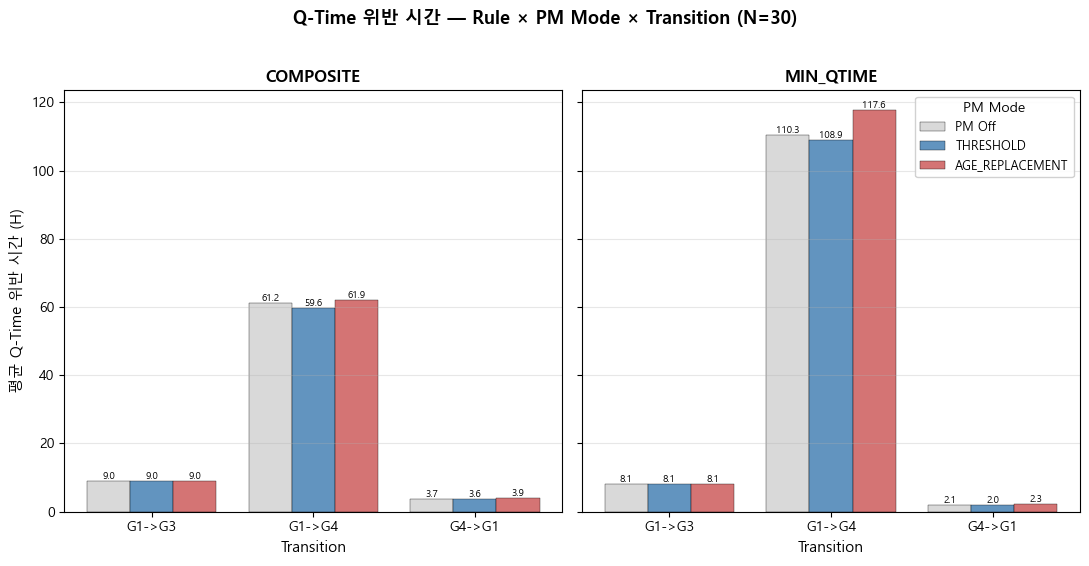

=== Q-Time 위반 평균 (시간) — rule × pm_mode × transition ===
pm_mode               PM Off  THRESHOLD  AGE_REPLACEMENT
rule      transition                                    
COMPOSITE G1->G3        9.04       9.04             9.04
          G1->G4       61.19      59.61            61.92
          G4->G1        3.68       3.62             3.91
MIN_QTIME G1->G3        8.05       8.05             8.05
          G1->G4      110.31     108.93           117.64
          G4->G1        2.08       1.95             2.29


In [9]:
# Rule × PM Mode × Transition 평균 위반 시간 (분 → 시간 변환).
# qtime이 설정된 transition만 의미 있는 값을 가짐.
QTIME_TRANSITIONS = ['G1->G3', 'G1->G4', 'G4->G1']  # CLAUDE.md: G1→G3(600), G1→G4(480), G4→G1(1440)

# run별 합계 → rule×pm_mode×transition 평균 (run에 없는 transition은 0으로 채움)
_full_idx = pd.MultiIndex.from_product(
    [rule_labels, PM_MODES, range(N_RUNS), QTIME_TRANSITIONS],
    names=['rule', 'pm_mode', 'run', 'transition'],
)
trans_per_run = (metrics_trans
                 .groupby(['rule', 'pm_mode', 'run', 'transition'])['violation']
                 .sum()
                 .reindex(_full_idx, fill_value=0.0)
                 .reset_index())
trans_summary = (trans_per_run
                 .groupby(['rule', 'pm_mode', 'transition'])['violation']
                 .mean()
                 .div(60.0)  # 분 → 시간
                 .reset_index())

fig, axes = plt.subplots(1, len(rule_labels),
                         figsize=(5.5 * len(rule_labels), 5.5), sharey=True)
if len(rule_labels) == 1:
    axes = [axes]

n_modes = len(PM_MODES)
width = 0.8 / n_modes
x = np.arange(len(QTIME_TRANSITIONS))

for ax, rule in zip(axes, rule_labels):
    sub = trans_summary[trans_summary['rule'] == rule]
    pivot = (sub.pivot(index='transition', columns='pm_mode', values='violation')
             .reindex(QTIME_TRANSITIONS)
             .reindex(PM_MODES, axis=1)
             .fillna(0.0))
    for m_idx, mode in enumerate(PM_MODES):
        vals = pivot[mode].values
        offset = (m_idx - (n_modes - 1) / 2) * width
        bars = ax.bar(x + offset, vals, width,
                      label=mode, color=PM_COLORS[mode], alpha=0.85,
                      edgecolor='black', linewidth=0.3)
        for bar, v in zip(bars, vals):
            if v > 0.05:
                ax.text(bar.get_x() + bar.get_width() / 2, v,
                        f'{v:.1f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(QTIME_TRANSITIONS, rotation=0)
    ax.set_xlabel('Transition', fontsize=11)
    ax.set_title(rule, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

axes[0].set_ylabel('평균 Q-Time 위반 시간 (H)', fontsize=11)
axes[-1].legend(title='PM Mode', loc='upper right', fontsize=9, framealpha=0.9)
plt.suptitle(f'Q-Time 위반 시간 — Rule × PM Mode × Transition (N={N_RUNS})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 표 출력 (시간 단위)
trans_table = (trans_summary
               .pivot_table(index=['rule', 'transition'],
                            columns='pm_mode', values='violation')
               .reindex(PM_MODES, axis=1)
               .reindex(pd.MultiIndex.from_product([rule_labels, QTIME_TRANSITIONS],
                                                    names=['rule', 'transition']))
               .round(2))
print("=== Q-Time 위반 평균 (시간) — rule × pm_mode × transition ===")
print(trans_table.to_string())


## COMPOSITE × AGE_REPLACEMENT 결과를 `ga_result.xlsx` 형식으로 저장

GA 결과(`ga_result.xlsx`)와 **동일한 3개 컬럼**(`best_makespan` / `best_qtime` / `best_fitness`)·**동일한 단위(시간, H)** 로 저장한다.

- `best_makespan` = makespan(분) / 60 → 시간
- `best_qtime` = AQT(분/job) / 60 → 시간 (job당 평균 q-time 위반)
- `best_fitness` = makespan/mk_ref + AQT/qv_ref_aqt → SAA 목적함수 `J` (w1=w2=1.0)

`mk_ref`/`qv_ref_aqt` 는 GA가 사용한 값과 동일하게 `tuning/full6_pso_result.json` 의 `config` 에서 읽으므로 fitness 정의가 GA와 정확히 일치한다.

In [10]:
# GA fitness 와 동일한 정규화 상수 로드 (tuning/full6_pso_result.json)
with open(os.path.join('tuning', 'full6_pso_result.json'), 'r', encoding='utf-8') as f:
    _pso_cfg = json.load(f)['config']
MK_REF     = float(_pso_cfg['mk_ref'])       # 분 단위 makespan 기준
QV_REF_AQT = float(_pso_cfg['qv_ref_aqt'])   # 분/job 단위 AQT 기준
W1, W2 = 1.0, 1.0                            # GA fitness 가중치와 동일
print(f"mk_ref = {MK_REF:.4f} (분), qv_ref_aqt = {QV_REF_AQT:.4f} (분/job)")

# COMPOSITE × AGE_REPLACEMENT 30회 결과만 추출 (위 PM=True 셀에서 생성된 metrics_all 사용)
_sel = (metrics_all[(metrics_all['rule'] == 'COMPOSITE') &
                    (metrics_all['pm_mode'] == 'AGE_REPLACEMENT')]
        .sort_values('run'))
if len(_sel) == 0:
    raise RuntimeError("COMPOSITE × AGE_REPLACEMENT 결과가 없습니다. 먼저 PM=True 실험 셀을 실행하세요.")

# ga_result.xlsx 와 동일한 컬럼/단위(시간)로 구성
ga_like = pd.DataFrame({
    'best_makespan': _sel['makespan'].values / 60.0,                       # 분 → 시간
    'best_qtime':    _sel['aqt'].values / 60.0,                            # 분/job → 시간
    'best_fitness':  W1 * (_sel['makespan'].values / MK_REF)
                     + W2 * (_sel['aqt'].values / QV_REF_AQT),             # SAA 목적함수 J
})

OUT_XLSX = 'composite_age_result.xlsx'
ga_like.to_excel(OUT_XLSX, index=False)
print(f"\n저장 완료 → {OUT_XLSX}  (shape={ga_like.shape}, 단위=시간)")
print(ga_like.describe().round(4).to_string())
ga_like


mk_ref = 14734.1579 (분), qv_ref_aqt = 1140.0048 (분/job)



저장 완료 → composite_age_result.xlsx  (shape=(30, 3), 단위=시간)
       best_makespan  best_qtime  best_fitness
count        30.0000     30.0000       30.0000
mean        220.5600      1.2480        0.9638
std           7.0729      0.8680        0.0699
min         205.7407      0.0000        0.8495
25%         216.6503      0.6907        0.9085
50%         220.1654      1.2324        0.9539
75%         223.7764      1.5932        1.0049
max         234.9098      3.8586        1.1568


,best_makespan,best_qtime,best_fitness
0,215.141643,1.449236,0.952369
1,220.282063,1.110106,0.955452
2,222.596450,1.548749,0.987963
3,223.561667,1.799913,1.005113
4,217.180833,0.263258,0.898253
5,218.034093,1.179777,0.949965
6,209.913725,0.674985,0.890330
7,226.615740,1.671006,1.010765
8,222.848244,1.284990,0.975107
9,229.797442,1.430458,1.011061


## (보조) PM Threshold 민감도 — Boxplot 시각화

**요청 1** 에서 계산한 `thr_df`(COMPOSITE + `PM_RULE=THRESHOLD`, `PM_HAZARD_THRESHOLD` ∈ {0.05, 0.1, 0.15, 0.3, 0.5, 0.7, 0.85}) 를 **재사용**해
분포를 boxplot 으로 시각화한다 (재실행 없음).

- **Graph 1** — Makespan(파랑) + Average Qtime Violation(빨강) boxplot을 **같은 그래프**에 (스케일 차이로 twin y-axis, × = 평균).
- **Graph 2** — 작업 중 고장 횟수(in-process breakdown) boxplot (별도).

In [11]:
# 민감도 분석 데이터는 "요청 1" 셀에서 이미 계산한 thr_df 를 그대로 재사용한다 (중복 실행 없음).
# (thr_df / PM_THRESHOLDS / run_simulation_pm_threshold / objective_J 는 요청 1 셀에서 정의됨)
if 'thr_df' not in globals():
    raise RuntimeError("thr_df 가 없습니다. 먼저 '요청 1 — PM Threshold 스윕' 셀을 실행하세요.")

print(f"thr_df 재사용 (shape = {thr_df.shape}) — PM_THRESHOLDS = {PM_THRESHOLDS}")

# threshold별 평균 요약 (boxplot 보조 수치)
thr_summary = thr_df.groupby('threshold').agg(
    makespan_mean=('makespan', 'mean'),
    qtime_violation_mean=('qtime_violation', 'mean'),
    inproc_bd_mean=('inproc_bd', 'mean'),
).round(2)
print("\n=== threshold별 평균 (Makespan/QV: 분, Breakdown: 횟수) ===")
print(thr_summary.to_string())

thr_df 재사용 (shape = (210, 8)) — PM_THRESHOLDS = [0.05, 0.1, 0.15, 0.3, 0.5, 0.7, 0.85]

=== threshold별 평균 (Makespan/QV: 분, Breakdown: 횟수) ===
           makespan_mean  qtime_violation_mean  inproc_bd_mean
threshold                                                     
0.05            18095.17              18662.22            5.70
0.10            15017.08               4465.03            7.67
0.15            14121.43               4985.41            9.40
0.30            13094.51               4278.76           14.20
0.50            12611.48               4336.67           18.77
0.70            12605.03               4435.19           20.37
0.85            12629.74               4435.19           20.43


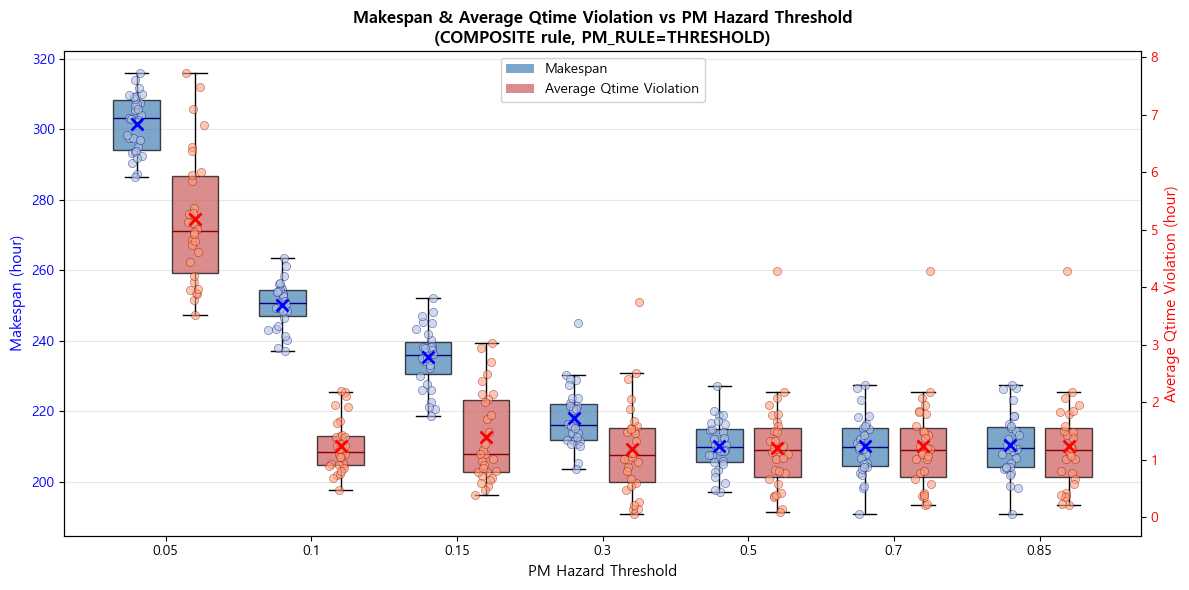

In [12]:
# ── Graph 1: Makespan (blue) + Average Qtime Violation (red) on the SAME plot ─
# 단위 = hour (내부 분 단위 → /60). Average Qtime Violation = QV_total / N_JOBS.
# 스케일 차이로 twin y-axis. 분포 점(jitter) + 평균(red x) 은 아래 breakdown 그래프와 동일 형식.
from matplotlib.patches import Patch

thr_labels = [str(t) for t in PM_THRESHOLDS]
positions = np.arange(len(PM_THRESHOLDS))
# Makespan: 분 → 시간
mk_data = [thr_df[thr_df['threshold'] == t]['makespan'].values / 60.0 for t in PM_THRESHOLDS]
# Average Qtime Violation: (분 총합 / N_JOBS) → 시간
aqv_data = [(thr_df[thr_df['threshold'] == t]['qtime_violation'].values / N_JOBS) / 60.0
            for t in PM_THRESHOLDS]

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Makespan — blue, left axis
bp_mk = ax1.boxplot(mk_data, positions=positions - 0.2, widths=0.32,
                    patch_artist=True, showfliers=False, manage_ticks=False)
for patch in bp_mk['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
for med in bp_mk['medians']:
    med.set_color('navy')
for i, vals in enumerate(mk_data):
    x_jit = [positions[i] - 0.2 + np.random.normal(0, 0.03) for _ in vals]
    ax1.scatter(x_jit, vals, alpha=0.6, s=35, color='lightsteelblue',
                edgecolors='navy', linewidth=0.4, zorder=3)
    ax1.plot(positions[i] - 0.2, np.mean(vals), marker='x', markersize=9,
             markeredgewidth=2, color='blue', zorder=5)

# Average Qtime Violation — red, right axis
bp_qv = ax2.boxplot(aqv_data, positions=positions + 0.2, widths=0.32,
                    patch_artist=True, showfliers=False, manage_ticks=False)
for patch in bp_qv['boxes']:
    patch.set_facecolor('indianred')
    patch.set_alpha(0.7)
for med in bp_qv['medians']:
    med.set_color('darkred')
for i, vals in enumerate(aqv_data):
    x_jit = [positions[i] + 0.2 + np.random.normal(0, 0.03) for _ in vals]
    ax2.scatter(x_jit, vals, alpha=0.6, s=35, color='lightsalmon',
                edgecolors='darkred', linewidth=0.4, zorder=3)
    ax2.plot(positions[i] + 0.2, np.mean(vals), marker='x', markersize=9,
             markeredgewidth=2, color='red', zorder=5)

ax1.set_xticks(positions)
ax1.set_xticklabels(thr_labels)
ax1.set_xlabel('PM Hazard Threshold', fontsize=11)
ax1.set_ylabel('Makespan (hour)', fontsize=11, color='blue')
ax2.set_ylabel('Average Qtime Violation (hour)', fontsize=11, color='red')
ax1.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')
ax1.set_title('Makespan & Average Qtime Violation vs PM Hazard Threshold\n'
              '(COMPOSITE rule, PM_RULE=THRESHOLD)',
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

ax1.legend(handles=[Patch(facecolor='steelblue', alpha=0.7, label='Makespan'),
                    Patch(facecolor='indianred', alpha=0.7, label='Average Qtime Violation')],
           loc='upper center', framealpha=0.9)
plt.tight_layout()
plt.show()

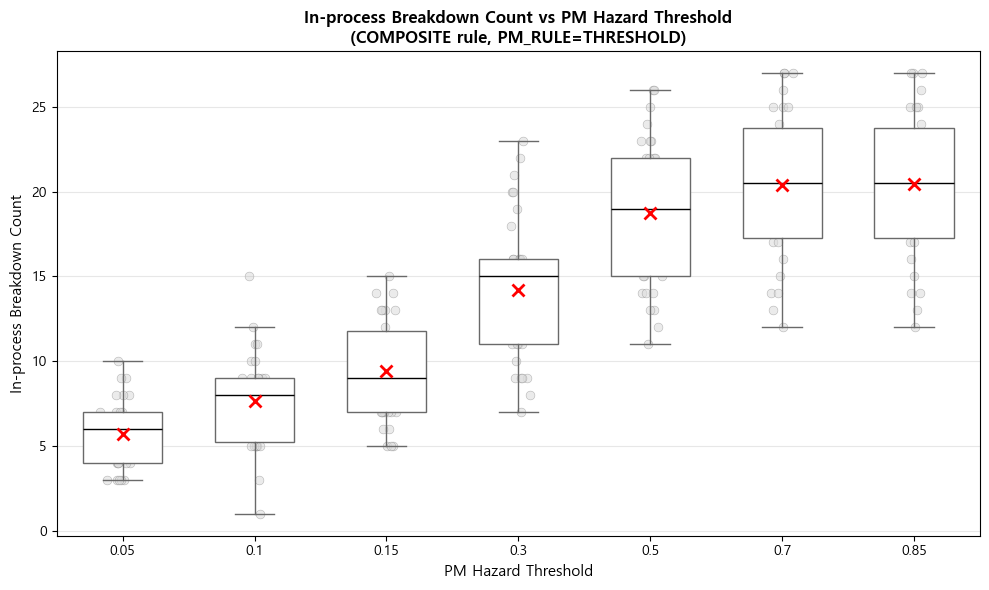

In [13]:
# ── Graph 2: In-process breakdown count (drawn separately) ──────────────────
bd_data = [thr_df[thr_df['threshold'] == t]['inproc_bd'].values for t in PM_THRESHOLDS]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(bd_data, tick_labels=thr_labels, patch_artist=True,
                widths=0.6, showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor('white')
    patch.set_edgecolor('dimgray')
for whisker in bp['whiskers']:
    whisker.set_color('dimgray')
for cap in bp['caps']:
    cap.set_color('dimgray')
for med in bp['medians']:
    med.set_color('black')

for i, vals in enumerate(bd_data):
    x_jit = [i + 1 + np.random.normal(0, 0.04) for _ in vals]
    ax.scatter(x_jit, vals, alpha=0.55, s=40, color='gainsboro',
               edgecolors='gray', linewidth=0.4)
    # red x = mean
    ax.plot(i + 1, np.mean(vals), marker='x', markersize=9,
            markeredgewidth=2, color='red', zorder=5)

ax.set_xlabel('PM Hazard Threshold', fontsize=11)
ax.set_ylabel('In-process Breakdown Count', fontsize=11)
ax.set_title('In-process Breakdown Count vs PM Hazard Threshold\n'
             '(COMPOSITE rule, PM_RULE=THRESHOLD)',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()